# Data exploration

In [3]:
import pandas as pd

from protest_impact.data.news.download import get_counts
from protest_impact.util import project_root

count_df_path = project_root / "data" / "news" / "monthly_counts.csv"
if count_df_path.exists():
    df = pd.read_csv(count_df_path)
else:
    df = get_counts()
    df.to_csv(count_df_path, index=False)
df["date"] = pd.to_datetime(df["date"])
df.head()

,newspaper,engine,date,count
0,abendblatt.de,google,2013-01-01,134
1,abendblatt.de,google,2013-02-01,122
2,abendblatt.de,google,2013-03-01,89
3,abendblatt.de,google,2013-04-01,133
4,abendblatt.de,google,2013-05-01,122


In [ ]:
import matplotlib.pyplot as plt

from protest_impact.data.plot_history import plot_history

plt.close()
plot_history(df, newspaper="noz.de")

<AxesSubplot: >

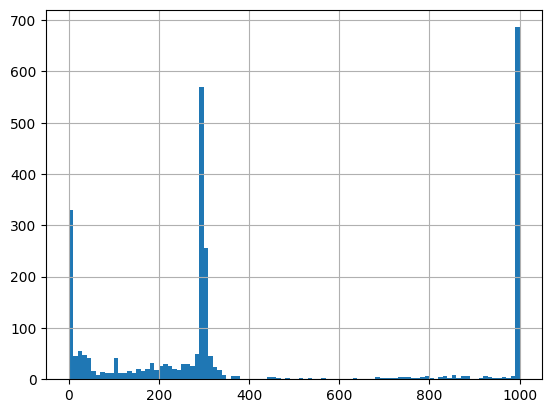

In [5]:
df_ = df.copy()
# aggregate the data by month (for each year) and newspaper
df_["month"] = df_["date"].dt.strftime("%Y-%m")
df_ = df_.groupby(["newspaper", "month"])["count"].sum().reset_index()
# plot the distribution of the number of articles per month
# cap the number of articles at 1000
df_["count"] = df_["count"].clip(upper=1000)
df_["count"].hist(bins=100)

<AxesSubplot: >

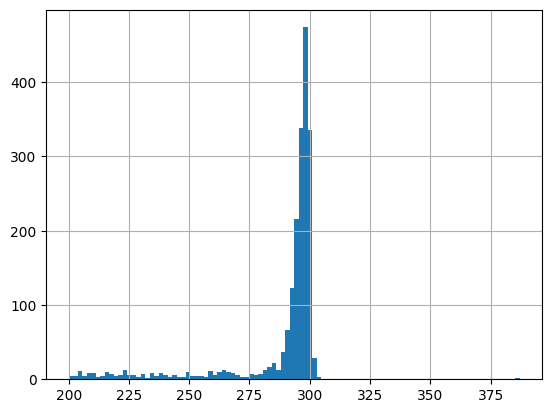

In [6]:
# plot the distribution for the values 200 to 400
df["count"][df["count"].between(200, 400)].hist(bins=100)

Output from `ncdu`:

```
    1.5 GiB [#####################] /noz.de
    1.1 GiB [##############       ] /bild.de
    1.0 GiB [#############        ] /tagesspiegel.de
  833.4 MiB [###########          ] /haz.de
  683.5 MiB [#########            ] /spiegel.de
  626.7 MiB [########             ] /stuttgarter-zeitung.de
  614.1 MiB [########             ] /n-tv.de
  408.1 MiB [#####                ] /rp-online.de
  335.9 MiB [####                 ] /weser-kurier.de
  324.6 MiB [####                 ] /bz-berlin.de
  321.0 MiB [####                 ] /t-online.de
  307.6 MiB [####                 ] /nordbayern.de
  304.5 MiB [####                 ] /welt.de
  299.7 MiB [####                 ] /rundschau-online.de
  262.9 MiB [###                  ] /zeit.de
  238.1 MiB [###                  ] /sueddeutsche.de
  233.0 MiB [###                  ] /stern.de
  222.7 MiB [##                   ] /shz.de
  212.6 MiB [##                   ] /faz.net
  211.9 MiB [##                   ] /fr.de
  211.2 MiB [##                   ] /abendblatt.de
  207.7 MiB [##                   ] /augsburger-allgemeine.de
  194.7 MiB [##                   ] /saarbruecker-zeitung.de
  191.0 MiB [##                   ] /op-online.de
  180.5 MiB [##                   ] /tz.de
  167.4 MiB [##                   ] /merkur.de
  136.2 MiB [#                    ] /waz.de
  132.6 MiB [#                    ] /maz-online.de
  125.0 MiB [#                    ] /thueringer-allgemeine.de
  123.4 MiB [#                    ] /heise.de
  121.8 MiB [#                    ] /schwaebische.de
  118.4 MiB [#                    ] /ostsee-zeitung.de
  117.7 MiB [#                    ] /focus.de
  116.5 MiB [#                    ] /nzz.ch
  113.6 MiB [#                    ] /wn.de
  110.7 MiB [#                    ] /infranken.de
  104.4 MiB [#                    ] /freiepresse.de
  103.3 MiB [#                    ] /derstandard.at
   93.4 MiB [#                    ] /tagesschau.de
   88.1 MiB [#                    ] /rnd.de
   87.5 MiB [#                    ] /saechsische.de
   84.6 MiB [#                    ] /rtl.de
   82.3 MiB [#                    ] /onetz.de
   69.5 MiB [                     ] /kreiszeitung.de
   66.9 MiB [                     ] /lvz.de
   63.3 MiB [                     ] /rheinpfalz.de
   62.5 MiB [                     ] /azonline.de
   56.3 MiB [                     ] /wa.de
   56.2 MiB [                     ] /solinger-tageblatt.de
   51.0 MiB [                     ] /wz.de
   50.7 MiB [                     ] /soester-anzeiger.de
   50.2 MiB [                     ] /m.focus.de
   49.4 MiB [                     ] /werra-rundschau.de
   49.2 MiB [                     ] /come-on.de
   49.0 MiB [                     ] /sauerlandkurier.de
   48.3 MiB [                     ] /dzonline.de
   46.6 MiB [                     ] /mz-web.de
   42.4 MiB [                     ] /zdf.de
   37.7 MiB [                     ] /braunschweiger-zeitung.de
   36.0 MiB [                     ] /mittelbayerische.de
   31.5 MiB [                     ] /salzgitter-zeitung.de
   31.2 MiB [                     ] /muensterschezeitung.de
   25.7 MiB [                     ] /tlz.de
   25.2 MiB [                     ] /lz.de
   24.5 MiB [                     ] /waz-online.de
   23.0 MiB [                     ] /szo.de
   19.9 MiB [                     ] /abendzeitung-muenchen.de
   15.2 MiB [                     ] /blog.zeit.de
   13.3 MiB [                     ] /otz.de
   11.6 MiB [                     ] /jungewelt.de
   11.1 MiB [                     ] /nw.de
    9.0 MiB [                     ] /jungefreiheit.de
 Total disk usage:  14.0 GiB  Apparent size:   7.0 GiB  Items: 3,022,678
```